# Part 13: Smoothing Relationships {-}

**Smoothing** refers generally to procedures that attempt to
extract underlying **signal** from **noise** in
a **nonparametric** manner. 

The term "nonparametric" means the use of a statistical model that does
not make restrictive assumptions. The data are allowed to "speak for
themselves" as much as possible.

Smoothing techniques are very commonly applied to situations where
one variable is naturally thought of as a **response**, i.e.,
a quantity to be predicted, and other variables are considered as **predictors**, i.e., the **regression** problem.

\newpage

## Example: Pricing Options {-}


A **European call option** on a stock is a contract
that gives the holder the right to purchase that stock at the
named **strike price** on the **expiration date**.

A **American call option** is the same, but allows the holder to
purchase the stock at that price **on or before** the expiration date.

The classic **Black-Scholes Theory** for option pricing establishes
a price for a European option as a function of the following: the strike price,
the time to expiration, the current asset price, the volatility of the price, and
the current risk-free rate of return.

We will consider a data set consisting of 1,000 call options
sampled on September 29, 2017.

To generate this sample, NYSE stock symbols were randomly chosen, and then
one currently-listed call option was randomly chosen for each equity,
weighted by the volume of trading.

Information recorded for each were as follows: The strike price, the time to
expiration, the current asset price, the historical volatility (based on daily
returns of 30 most recent trading days), the **implied volatility**
and the Black-Scholes price for the option (with a risk-free rate of zero
assumed).

\newpage

This sample can be found in the Data Sets area on Canvas, with
the name `optionssample09302017.txt`.

In [1]:
import pandas as pd

optionsdata = \
   pd.read_csv("optionssample09302017.txt", sep=",")

Our objective is to explore the relationships between the
current ask price for the option and the available variables.

This is an "empirical" alternative to Black-Scholes theory,
whose limitations are well-known, mainly due to the failure
of the underlying normality assumption.

\newpage

A classic manifestation of the failure of Black-Scholes is
the so-called **volatility smile**. Under the
theory, a plot of implied volatility versus how far
"in the money" the option currently is should be flat for
options with the same expiration date.

Let's create this plot in our case. Is there evidence of the
smile here?

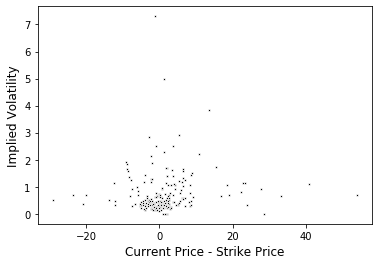

In [2]:
optionsdata["inmoney"] = \
  optionsdata["curprice"] - optionsdata["strike"]

optionsdata20 = \
  optionsdata[optionsdata["timetoexpiry"] == 20]

import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.scatterplot(x="inmoney", y="implvol",
      data=optionsdata20, s=5, color="black")
plt.xlabel("Current Price - Strike Price", size=12)
plt.ylabel("Implied Volatility", size=12)
plt.show()

The seaborn function `lmplot()` allows for the inclusion of a smoothed version of the relationship between the variables. This can be done
by setting `lowess = True`.

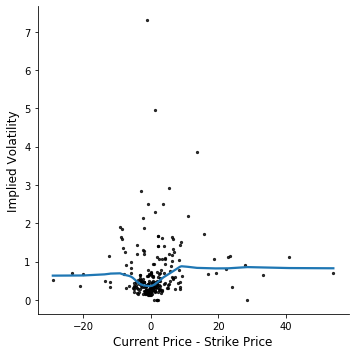

In [3]:
sns.lmplot(x="inmoney", y="implvol",
     data=optionsdata20, lowess=True,
     scatter_kws={"s": 5, "color": "black"})
plt.xlabel("Current Price - Strike Price",size=12)
plt.ylabel("Implied Volatility",size=12)
plt.show()

\newpage

**Exercise:** Comment on the addition of the smooth to the plot.

\answerlines{5}

\newpage

## Local Linear Regression {-}

The figure on the previous page shows a **nonparametric regression**
or **nonparametric smooth** of the scatter plot.

There are many variants of nonparametric regression, but here we focus
on
**local linear regression**,
a version of **local polynomial regression**. This approach has
proven to be very powerful, and possesses many strong theoretical
properties to justify its use.

Briefly stated, this procedure works by fitting a sequence of
linear models: Each is fit not to the entire data set, but
to only data within a **neighborhood** of a target point.
The size of this neighborhood is a **smoothing parameter**: Large
neighborhoods yield a large degree of smoothing, while small
neighborhoods result in minimal smoothing.

\newpage

Our model here is that we observe $(x_i, Y_i)$ for $i=1,2,\ldots,n$
and that
\begin{equation*}
   Y_i = f(x_i) + \epsilon_i
\end{equation*}
where the $\epsilon_i$ are iid with mean zero and variance $\sigma^2$.
Assuming that the $\epsilon_i$ are normal will lead to further nice
properties, but this development does not require that assumption.

In order to construct the local linear regression estimate of $f(\cdot)$,
it is best to consider a sequence of steps **for each fixed
$x_0$ at which $f(\cdot)$ will be estimated**.

\newpage

**Step One: Fix the target point $x_0$.**

Our objective is to estimate the regression function at $x_0$.

![Step One](LLRdemo/step1.png)

\newpage

**Step Two: Create the neighborhood around $x_0$.**

A common
way to choose the neighborhood size is to choose is large enough
to capture proportion $\alpha$ of the data. This
parameter $\alpha$ is often called the **span**. A typical
choice is $\alpha \approx 0.5$.

![Step Two](LLRdemo/step2.png)

\newpage

**Step Three: Weight the data in the neighborhood.**

Values of $x$ which
are close $x_0$ will receive a larger weight than those far from $x_0$.
Denote by $w_i$ the weight placed on observation $i$.
A typical default choice is the **tri-cube weight function**:
\begin{equation*}
   w_i = \left\{ \begin{array}{ll}
   \left(1-\left|\frac{x_i-x_0}{\mbox{max dist}}\right|^3\right)^{\! 3}, & \mbox{if $x_i$ in the neighborhood of $x_0$} \\
   0, & \mbox{if $x_i$ is not in neighborhood of $x_0$}
\end{array}
   \right.
\end{equation*}

![Step Three](LLRdemo/step3.png)

\newpage

**Step Four: Fit the local regression line.**

This is done by finding $\beta_0$ and $\beta_1$ to minimize the weighted sum of squares
\begin{equation*}
   \sum_{i=1}^n w_i \left(y_i - \left(\beta_0 + \beta_1 x_i\right)\right)^2
\end{equation*}

![Step Four](LLRdemo/step4.png)

\newpage

**Step Five: Estimate $f(x_0)$.**

This is done using the fitted regression line to estimate the regression
function at $x_0$:
\begin{equation*}
   \widehat f(x_0) = \widehat \beta_0 + \widehat \beta_1 x_0
\end{equation*}

![Step Five](LLRdemo/step5.png)

\newpage

This is implemented in Python using `lowess()` in `statsmodels`. Note that the argument `frac` controls the span. The output of `lowess()` is a two-column matrix, where the first column is the sorted predictor values in the training set, and the second column is the fitted value for each.

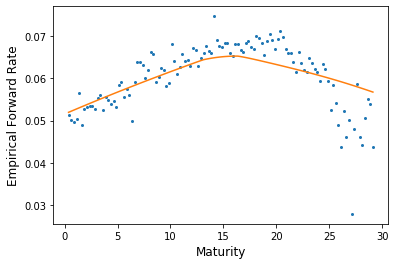

In [4]:
import pandas as pd


forratedat = pd.read_csv(
 "http://www.stat.cmu.edu/~cschafer/MSCF/forratedat.txt",
 sep=" ")

import statsmodels.api as sm

lowout = sm.nonparametric.lowess(forratedat['emp'],
         forratedat['maturity'], frac=0.90)

fig, axs = plt.subplots(1, 1, figsize=[6,4])
axs.plot(forratedat['maturity'],forratedat['emp'],
             marker='.', ms=4, linestyle="none")
axs.set_xlabel("Maturity", size=12)
axs.set_ylabel("Empirical Forward Rate", size=12)
axs.plot(lowout[:,0],lowout[:,1])
plt.show()

**Exercise:** Try refitting the model varying the span. Describe the effect.

\answerlines{8}

\newpage 

Let's also revisit the options example from above.

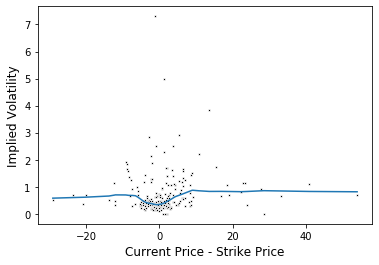

In [5]:
lowopt = \
  sm.nonparametric.lowess(optionsdata20['implvol'],
  optionsdata20['inmoney'], frac=0.5)

ax = sns.scatterplot(x="inmoney", y="implvol",
      data=optionsdata20, s=5, color="black")
plt.xlabel("Current Price - Strike Price", size=12)
plt.ylabel("Implied Volatility", size=12)
plt.plot(lowopt[:,0], lowopt[:,1])
plt.show()

\newpage

## Smoothing parameter selection in Regression {-}

We saw above that the choice of the span (the smoothing parameter) controls how
"smooth" the resulting estimate is: A smaller value leads to a "rougher"
estimate, a larger value gives a "smoother" estimate.

**Exercise:** Explain how the choice of the smoothing parameter relates to
the **bias/variance tradeoff**.

\answerlines{10}

\newpage

Automated approaches to smoothing parameter selection do exist. Different ideas
are available, but a very popular approach is based on **cross validation**.

As we saw before, the motivation behind cross validation is that we seek a
regression function that
makes accurate predictions for **new** observations, not for those that are used
to fit the model. A regression function that makes accurate predictions only for
training data is said to be **overfit**.

**Exercise:** Discuss how nonparametric regression, and the choice of the
smoothing parameter, leads to increased risk of overfitting. Does choosing
the smoothing parameter to minimize residual sum of squares seem like a good idea?

\answerlines{10}

\newpage

The **residual sum of squares** in this case is
\begin{equation*}
\mbox{RSS} = \sum_{i=1}^n \left(Y_i - \widehat f_{\!h}\!\left(x_i\right)\right)^2
\end{equation*}
where $\widehat f_{\!h}\!\left(x_i\right)$ is the estimate of the regression
function $f()$ when smoothing parameter $h$ is used.

Instead of choosing $h$ to minimize ${\rm RSS}$, we minimize the
\textcolor{red}{leave-one-out cross validation score}:
\begin{equation*}
  \mbox{LOOCV} = \sum_{i=1}^n \left(Y_i - \widehat f_{\!h}^{(-i)}\!\left(x_i\right)\right)^2
\end{equation*}
where $f_{\!h}^{(-i)}\!\left(x_i\right)$ is the estimate of
the regression function **when the $i^{th}$ observation
is excluded from the training set**.

Again, the idea here is that, by leaving out observation $i$, we are treating
it as if it were a "new" observation, and testing to see how well this
choice of $h$ does in predicting the response.

\newpage

**Exercise:** We note that for local linear regression, it is possible to write out a matrix ${\bf M}$ such that $\hat {\bf Y} = {\bf M} {\bf Y}$. What are the implications for the calculation of the leave-one-out cross validation score, and for the calculation of AIC?

\answerlines{15}

\newpage

There is an R function `loess.as()`, which is part
of the package `fANCOVA`, which has automatic selection of
the span.

In [6]:
import rpy2
%load_ext rpy2.ipython

Note the syntax for `loess.as()`: The predictor vector is given first, then the response. The criterion can be either `gcv` or `aicc`. "GCV" stands for **generalized cross validation**, which is an approximation to leave-one-out cross-validation. "AICC" is a "corrected" version of AIC.

The component `holdlo2$pars$span` holds the optimal span.

In [12]:
%%R -i forratedat -o optspan

library(fANCOVA)
holdlo = loess.as(forratedat$maturity, 
      forratedat$emp, criterion = "aicc")
optspan = holdlo$pars$span

In [17]:
optspan[0]

0.7038925300366445

\newpage

Let's remake the plot.

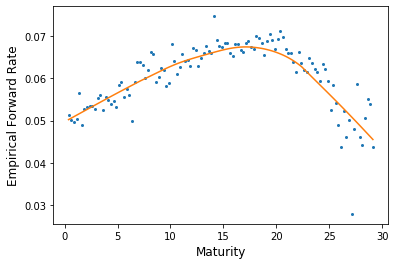

In [14]:
lowout = sm.nonparametric.lowess(forratedat['emp'],
         forratedat['maturity'], frac=optspan[0])

fig, axs = plt.subplots(1, 1, figsize=[6,4])
axs.plot(forratedat['maturity'],forratedat['emp'],
             marker='.', ms=4, linestyle="none")
axs.set_xlabel("Maturity", size=12)
axs.set_ylabel("Empirical Forward Rate", size=12)
axs.plot(lowout[:,0],lowout[:,1])
plt.show()

**Exercise:** Comment on the quality of this fit. Use `criterion="aicc"` instead. How does the performance change? What do you think happened?

\answerlines{10}

\newpage

Let's now reconsider the options example.

In [15]:
%%R -i optionsdata20 -o optspan

holdlo = loess.as(optionsdata20$inmoney, 
      optionsdata20$implvol, criterion = "gcv")
optspan = holdlo$pars$span

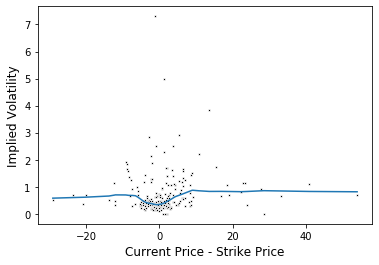

In [16]:
lowopt2 = \
  sm.nonparametric.lowess(optionsdata20['implvol'],
  optionsdata20['inmoney'], frac=optspan[0])

ax = sns.scatterplot(x="inmoney", y="implvol",
      data=optionsdata20, s=5, color="black")
plt.xlabel("Current Price - Strike Price", size=12)
plt.ylabel("Implied Volatility", size=12)
plt.plot(lowopt[:,0], lowopt[:,1])
plt.show()